In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_parquet("../data/flights_sample_2022.parquet")
df.shape

df.head()
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 61 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   FlightDate                               100000 non-null  datetime64[ns]
 1   Airline                                  100000 non-null  object        
 2   Origin                                   100000 non-null  object        
 3   Dest                                     100000 non-null  object        
 4   Cancelled                                100000 non-null  bool          
 5   Diverted                                 100000 non-null  bool          
 6   CRSDepTime                               100000 non-null  int64         
 7   DepTime                                  97092 non-null   float64       
 8   DepDelayMinutes                          97092 non-null   float64       
 9   DepDelay                   

,FlightDate,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,ArrTime,ArrDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,...,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,DistanceGroup,DivAirportLandings
count,100000,100000.000000,97092.00000,97092.000000,97092.000000,96987.000000,96759.000000,96759.000000,100000.00000,96759.000000,...,97025.000000,97025.000000,96987.000000,96987.000000,100000.000000,96759.000000,96759.000000,96759.000000,100000.000000,100000.000000
mean,2022-04-18 14:10:54.624000256,1328.719910,1333.61381,16.178635,13.258662,1457.158898,15.968282,111.099154,141.44746,135.968892,...,16.979593,1355.173821,1454.180581,7.902276,1486.492700,7.697237,0.216073,-0.053432,3.665410,0.003800
min,2022-01-01 00:00:00,1.000000,1.00000,0.000000,-55.000000,1.000000,0.000000,9.000000,5.00000,16.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-86.000000,0.000000,-2.000000,1.000000,0.000000
25%,2022-02-25 00:00:00,913.000000,916.00000,0.000000,-5.000000,1046.000000,0.000000,60.000000,89.00000,83.000000,...,11.000000,931.000000,1043.000000,4.000000,1103.000000,-14.000000,0.000000,-1.000000,2.000000,0.000000
50%,2022-04-19 00:00:00,1320.000000,1324.00000,0.000000,-1.000000,1459.000000,0.000000,94.000000,125.00000,119.000000,...,15.000000,1337.000000,1456.000000,6.000000,1513.000000,-5.000000,0.000000,-1.000000,3.000000,0.000000
75%,2022-06-11 00:00:00,1735.000000,1744.00000,11.000000,11.000000,1914.000000,10.000000,141.000000,172.00000,167.000000,...,19.000000,1758.000000,1909.000000,9.000000,1920.000000,10.000000,0.000000,0.000000,5.000000,0.000000
max,2022-07-31 00:00:00,2359.000000,2400.00000,1677.000000,1677.000000,2400.000000,1666.000000,667.000000,690.00000,690.000000,...,175.000000,2400.000000,2400.000000,251.000000,2359.000000,1666.000000,1.000000,12.000000,11.000000,9.000000
std,NaN,491.085319,506.13566,52.412291,53.423751,543.531909,52.156268,70.053862,71.91191,72.006964,...,9.445704,508.239335,538.359867,6.730599,518.289396,55.443698,0.411567,2.503599,2.322747,0.117922


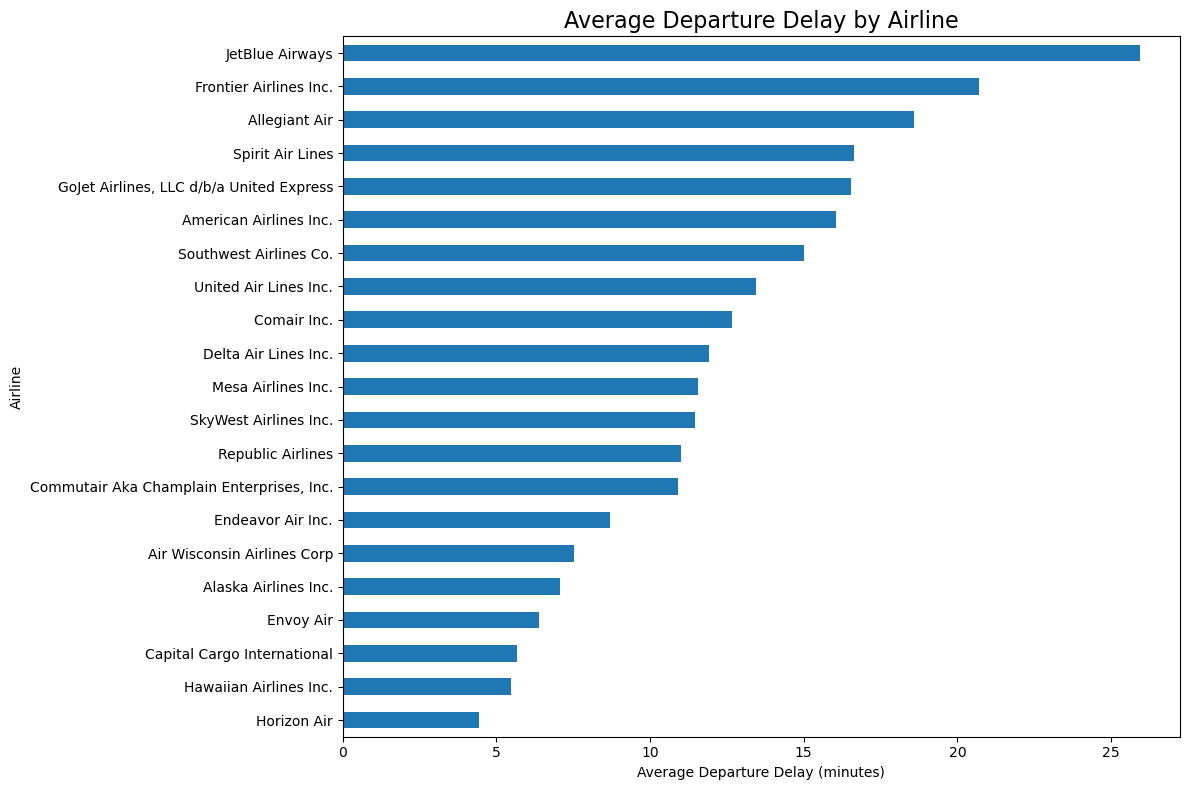

In [22]:
airline_delays = (
    df.groupby("Airline")["DepDelay"]
    .mean()
    .sort_values(ascending=False)
)
airline_delays

plt.figure(figsize=(12,8))
airline_delays.sort_values().plot(kind="barh")
plt.title("Average Departure Delay by Airline", fontsize=16)
plt.xlabel("Average Departure Delay (minutes)")
plt.ylabel("Airline")
plt.tight_layout()
plt.savefig("../visuals/airline_delay_bar_chart.png")
plt.show()